# 🦾🧠 **基于 Red Hat OpenShift AI 运行 MLOps**

## **目录**

- 1. 机器学习的基本概念
- 2. 机器学习的类型
- 3. 机器学习架构的概念
- 4. 典型的机器学习模型训练过程
- 5. 机器学习常用评估指标
- 6. MLOps 典型流程
- 7. RHOAI 的高层次 (High-level) 架构
- 8. RHOAI 中的 AI/ML 工作流示意
- 9. 部署 Red Hat OpenShift AI (RHOAI)
- 10. 关于 JupyterLab 与 Notebook 的使用
- 11. NumPy 数组（NumPy Arrays）
- 12. 数据探索与预处理：Pandas
- 13. 数据探索与预处理：Matplotlib
- 14. Scikit-learn 库使用示例
- 15. PyTorch 库使用示例
- 参考链接

## **1. 机器学习的基本概念**

- 特征（features）
- 目标变量（target variables）：标记数据（可包含连续的数值）
- 超参数（hyperparameters）
- 模型（model）
- 训练（training）
- 推理（inference）
- 评估（evalution）：为了评估训练后数据集中的预期值与模型生成的实际值之间的偏差，计算偏差或性能使用均方根误差、精确率与召回率等指标。

## **2. 机器学习的类型**

- 监督学习：
  - 此类学习方式会从标记的数据中学习
  - **模型类型**：线性回归、逻辑回归、支持向量机（Support Vector Machine, SVM）、决策树（Decision Tree, DT）、随机森林（Random Forest, RF）、神经网络（Neural Network, NN）
- 无监督学习：
  - 此类学习方式会从未标记的数据中学习，以发现数据中隐藏的结构或见解，而无需有关目标的明确指导。在这种情况下，数据集不包含目标变量。
  - **模型类型**：自组织映射（SOM）、K 均值聚类（K-means clustering）、K 最邻近（KNN）、主成分分析（PCA）、自动编码神经网络
  - 大语言模型（LLM）属于无监督学习范畴

## **3. 机器学习架构的概念**

<center><img src="images/desired-conceptual-ml-architecture.png" style="width:80%"></center>
  
- 在顶部，可看到一个典型的项目生命周期，其中设置了业务目标，数据工程师致力于收集和准备数据，以便为数据科学家开发 ML 模型做好准备。
- 接下来，数据科学家与软件开发人员合作，将 ML 模型部署到应用程序开发过程中。
- 最后，部署了人工智能/机器学习驱动的智能应用程序，机器学习模型开始根据它看到的新数据进行推理（做出预测）。
- 必须持续监控和管理生产中的 ML 模型，以确保它们做出正确的预测，并根据需要进行再训练。

## **4. 典型的机器学习模型训练过程**

<center><img src="images/04-machine-learning-model-by-youtube.jpg" style="width:60%"></center>

🍳 🫑🥒🥕🌽 🍱
就像做一道菜一样，需要准备食材、清洗、烹饪，最后还要品尝一下味道如何。数据科学也是这么个过程，只不过我们的食材是数据，最终的菜肴是一个能 **预测** 或 **分类** 的模型。

首先，我们得有原材料，也就是 **数据集**。这些数据可能是数字、文字，甚至是图像。数据集就像一个大杂烩，里面可能什么都有，所以我们得先做 **数据清洗**。这就像是洗菜，把没用的、错误的数据去掉，只留下我们需要的。有时候我们还会做 **数据整理**，这就像是把菜切好，方便后续的烹饪。

接下来，我们要做 **数据探索分析**，这就像是尝一尝菜的味道，看看哪些食材是我们需要的，哪些是可以扔掉的。我们会用一些方法，比如 **主成分分析（PCA）** 或者 **自组织映射（SOM）**，来帮助我们理解数据。

然后，我们要把数据分成 **训练集** 和 **测试集**。这就像是把食材分成两部分，一部分用来做菜，另一部分用来品尝。**训练集占了80%，测试集占了20%。** 我们用训练集来训练我们的模型，就像是用食材做菜，而测试集则用来检验我们的菜做得好不好。

接下来，我们要选择一些学习算法，比如支持向量机（SVM）、决策树（DT）或者K最近邻（KNN）。这些算法就像是不同的烹饪方法，有的适合做汤，有的适合炒菜。我们还会进行 **超参数优化** 和 **特征选择**，这就像是调整火候和选择调料，让菜做得更好吃。

然后，我们用训练好的模型来预测一些值，这就像是把菜端上桌，看看它的味道如何。我们还会用 **交叉验证** 来确保我们的模型不是偶然做对了，而是真正学会了做菜。

最后，我们要 **评估模型的性能**，这就像是品尝我们的菜，看看它的味道、色泽和口感如何。我们会用一些指标，比如准确度（Accuracy）、召回率（Recall）或者均方根误差（RMSE），来评价我们的模型。

## **5. 机器学习常用评估指标**

📢 本文中提到的术语：阳性样本 → 正样本或正例，阴性样本 → 负样本或负例

在整个机器学习的生命周期中，评估指标扮演着至关重要的角色：

- 模型选择：在多个模型中，选择在特定指标上表现最好的那个。
- 模型调优：评估指标指导调整模型的超参数，以达到更好的性能。
- 进度跟踪：**在模型训练迭代过程中，监控指标的变化趋势，判断模型是否收敛，或者是否存在欠拟合/过拟合等问题。**
- 性能监控：确保模型部署后依然能保持预期的性能水平。

选择合适的评估指标至关重要，因为它直接影响对模型 “好坏” 的定义。不同的业务场景和问题类型可能需要关注不同的指标。例如，在 **<span style="color: blue">医疗诊断</span>** 中，可能更关注召回率（不错过真正患病的人），而在 **<span style="color:blue">垃圾邮件识别</span>** 中，可能更关注精确率，因为它不能把正常邮件误判为垃圾邮件（不错杀好邮件）。

### **5.1 分类任务的评估指标**

在机器学习中，混淆矩阵、准确率、精确率、召回率和马修斯相关系数是评估 **模型分类性能（二分类或多分类）** 的不同统计指标。通常用于衡量模型预测结果（predicted class）与真实标签（actual class）之间的一致性（监督学习）。

- 🔀 **混淆矩阵：**

  - 混淆矩阵是一个 $C \times C$ 的矩阵，其中 $C$ 是类别数量，如二分类任务 $C$ 为 2（$2 \times 2$ 矩阵）。
  - 矩阵的行 ($i$) 表示真实标签，矩阵的列 ($j$) 表示模型预测的标签。
  - 二分类或多分类任务中，每个元素 $M_{ij}$ 表示，实际类别为第 $i$ 类，模型预测为第 $j$ 类的样本数量。

<center><img src="images/Confusion-Matrix-1-modified.jpeg" style="width:60%"></center>

<center>图 5.1.1：混淆矩阵（二分类任务）</center>

- 1️⃣ **准确率：**

  - **<span style="color:red">Accuracy (AC)</span>** 是最常用的性能指标之一
  - 目标：它衡量的是 **模型正确预测的样本数占总样本数的比例**。
  - 公式：$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$ 其中：TP 是 **真阳性**（True Positives），TN 是 **真阴性**（True Negatives），FP 是 **假阳性**（False Positives），FN 是 **假阴性**（False Negatives）。
  - 适用场景：它最直观地反映了模型的整体判断能力，适用于类别分布均衡的场景。
  -  缺点：在数据集平衡时，准确率是一个可靠的指标。在数据不平衡时容易产生误导。例如，如果一个二分类任务中负样本数量（99%）远高于正样本数量（1%），即使模型可以总是预测到负样本，准确率很高，但模型总是识别不到正样本。
  - 不平衡比（imbalance ratio, IR）：
    - 公式：$$\text{IR} = \frac{\text{the-majority-of-sample-numbers}}{\text{the-minority-of-sample-numbers}}$$ 其中多数样本数或少数样本数可以是正样本数整体或者负样本整体。
    - 常规判断标准：
      - $IR ≈ 1$ → 基本平衡
      - $IR ≤ 3$ → 轻度不平衡
      - $IR ≤ 10$ → 中度不平衡
      - $IR > 10$ → 重度不平衡（需重采样、代价敏感、阈值移动等手段）
    - 一句话：IR 越大，少数类越稀少，模型越容易 “偷懒” 把全部样本判成多数类。

- 2️⃣ **精确率：**

  - **<span style="color:red">Precision</span>** 也称为查准率、真正例率、单一类准确率
  - 目标：
    - 它衡量的是 **在所有被模型预测为正的样本中，实际也为正的比例**（图 5.1.1 中蓝框）。
    - 它关注模型预测的正样本中有多少是真的正样本。
    - 高精确率意味着低误报率。
  - 公式：$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
  - 适用场景：当误报（FP）成本很高时，如垃圾邮件过滤（把正常邮件标成垃圾邮件的成本很高）。

- 3️⃣ **召回率：**

  - **<span style="color:red">Recall</span>** 也称为灵敏度（Sensitivity, SN）、真阳性率（True Positive Rate, **TPR**）。
  - 目标：
    - 它衡量的是 **在所有实际为正的样本中，被模型正确预测为正的比例**（图 5.1.1 中绿框）。
    - 它衡量了模型找出所有正类样本的能力。
    - 高召回率意味着低漏报率。
  - 公式：$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
  - 适用场景：当漏报成本很高时，如疾病诊断、金融欺诈检测（错过欺诈行为的成本很高）。

- 4️⃣ **$F_\beta$ 分数（$F_\beta$ Score）：**

  - $F_\beta$ Score 是精确率和召回率的调和平均数。它在两者之间提供了一个平衡的度量，特别适用于类别不平衡的场景，相比准确率更有用。
  - 公式：$$F_\beta = (1+\beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$
  - $\beta$ 取值为 1 时，形如下式：$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
  - 其中 $\beta$ 为 Recall 相对 Precision 的权重倍数，实际使用是 $\beta^2$。
  - 重要含义：**$F_\beta$ 值越大，模型在少数类上即找的全又找的准（二分类与多分类均适用）。**

  | 场景 | minority class | 代价侧重 | 常用 $\beta$ | Recall 相对 Precision 的权重比（$\beta^2$） |
  | ----- | ----- | ----- | ----- | ----- |
  | **垃圾邮件** | 垃圾 | 误报打扰 → 精确优先 | 0.5（$F_{0.5}$） | 0.25:1 |
  | **搜索/推荐** | 相关结果 | 二者兼顾 | 1（$F_1$） | 1:1 |
  | **金融欺诈** | 欺诈交易 | 漏掉损失大 | 2（$F_2$） | 4:1 |
  | **乳腺癌筛查** | 恶性 | 漏诊要命 → 召回优先 | 2 或 4（$F_2$ 或 $F_4$） | 4:1 或 16:1 |

- 5️⃣ **AUC-ROC 曲线：**

  - ROC 曲线描绘了在不同分类阈值下，模型的真阳性率（$y$ 轴）与假阳性率（$x$ 轴）之间的关系。
  - 真阳性率（召回率）：$TPR = \frac{\text{TP}}{\text{TP} + \text{FN}}$
  - 假阳性率（误识率）：$FPR = \frac{\text{FP}}{\text{FP} +\text{TN}}$
  - AUC 是 ROC 曲线下方的面积，AUC 值越大（接近 1）越好，表示模型性能越优，且不受类别不平衡的影响。

<center><img src="images/AUC-ROC-Curve-2.png" style="width:60%"></center>

<center>图 5.1.2：AUC-ROC 曲线模式图</center>

- 6️⃣ **MCC (Matthews Correlation Coefficient)**:

  - **马修斯相关系数**（Matthews Correlation Coefficient, MCC）是一个介于 -1 和 1 之间的指标，用于衡量 **分类模型的质量**。MCC 考虑了所有四个混淆矩阵（confusion matrix）的组成部分（TP, TN, FP, FN），因此它提供了一个平衡的性能度量。
  - 计算公式为：$$\text{MCC} = \frac{\text{TP} \times \text{TN} - \text{FP} \times \text{FN}}{\sqrt{(\text{TP} + \text{FP}) \times (\text{TP} + \text{FN}) \times (\text{TN} + \text{FP}) \times (\text{TN} + \text{FN})}}$$
  - ✔️ MCC 值越高，表示模型的性能越好。MCC 为 1 表示完美预测，0 表示随机预测，-1 表示完全错误的预测。
  - ✔️ MCC 特别适用于类别不平衡的数据集，因为它不依赖于任何特定类别的预测。

### **5.2 回归任务的评估指标**

👉 在机器学习中，均方误差（Mean Squared Error, **MSE**）和均方根误差（Root Mean Squared Error, **RMSE**）是用来衡量模型预测值（$\hat{y}$）与实际值（$y$）之间差异的常用指标，尤其在回归任务中。

- 1️⃣ **MSE (Mean Squared Error)**：

  - 定义：**所有样本预测误差的平方和的平均值**
  - 公式：$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$  其中：$n$ 是样本数量；$y_i$ 是第 $i$ 个真实值；$\hat{y}_i$ 是第 $i$ 个预测值
  - ✔️ MSE 的值越小，表示模型的预测越准确。
  - ✔️ MSE 对于较大的误差给予更大的惩罚（因为误差是平方的），这使得模型更加关注减少较大的预测误差，对异常值（离散值）敏感。

- 2️⃣ **RMSE (Root Mean Squared Error)**：

  - 定义：MSE 的平方根
  - 公式：$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
  - RMSE 与 MSE 相似，但它将误差的单位还原为目标变量的单位，使得误差更直观。RMSE 同样对较大的误差给予较大的惩罚，对异常值（离散值）敏感。
  - MSE 与 RMSE 的关系：
    - RMSE 是 MSE 的平方根，因此它们衡量的是相同的误差，但 RMSE 的单位与目标变量的单位相同，而 MSE 的单位是目标变量单位的平方。
    - 由于平方根是一个凸函数，RMSE 对异常值的敏感度低于 MSE。这意味着在存在异常值的情况下，RMSE 可能不会像 MSE 那样显著增加。
  - 应用场景：
    - **MSE**：当需要一个对大误差有更大惩罚的指标时，或者想要优化的损失函数是二次损失（平方损失，形如 $\mathcal{L}(y_i, \hat{y_i}) = (y_i - \hat{y_i})^2$）时，MSE 是一个好选择。
    - **RMSE**：当需要一个与数据在同一单位上的误差指标时，RMSE 更合适。它通常用于金融和天气预报等领域。
    - 在实际应用中，选择 MSE 还是 RMSE 取决于具体问题的需求和对异常值的敏感度。通常，这些指标会与其他指标（如 MAE - Mean Absolute Error）一起使用，以全面评估模型的性能。

- 3️⃣ **MAE (Mean Absolute Error):**

  - 定义：平均绝对误差。**所有样本预测值与真实值差的绝对值的平均。**
  - 它直接量化了预测值与真实值之间的平均偏离程度。
  - 它对所有误差一视同仁，不会像 MSE/RMSE 那样放大大误差。因此，MAE 对异常值（离散值）鲁棒性较好。
  - 公式：$$\text{MAE} = \frac{1}{n}\sum\limits_{i=1}\limits^{n} \vert{y_i - \hat{y_i}}\vert$$

- 4️⃣ **$R^2$ 绝对系数：**

  - 它衡量模型对数据的变异性的解释程度。简单来说，它表示模型预测结果的方差与真实值方差的吻合程度。
  - $R^2$ 越接近 1，表示模型拟合效果越好；$R^2$ 为 0，表示模型性能与简单地用目标变量均值 $\overline{y}$ 预测一样差；$R^2$ 为负值，表示模型比基准模型（用平均值预测）还差。这里所说的基准模型是无论任何样本，预测值始终等于均值（$y_i = \overline{y}$）
  - 公式：$$R^2 = 1 - \frac{\sum\limits_{i=1}\limits^{n} (y_i - \hat{y_i})^2}{\sum\limits_{i=1}\limits^{n} (y_i - \overline{y})^2}$$  其中：$\overline{y} = \frac{1}{n} \sum\limits_{i=1}\limits^{n} y_i$，是真实值的平均值。

## **6. MLOps 典型流程**

<center><img src="images/typical-MLOps-workflow.png" style="width:80%"></center>

<center><img src="images/ml-workflow.jpg" style="width:80%"></center>

## **7. RHOAI 的高层次 (High-level) 架构**

  <center><img src="images/01-rhoai-advanced-architecture.jpg" style="width:80%"></center>
  
  RHOAI 中模型开发与训练位于 workbench 中进行，它在整个 MLOps 中具有核心的地位。以下列举了 workbench 的镜像来源与架构：
  
  <center><img src="images/workbench-architecture.png" style="width:80%"></center>
  
  🔥 RHOAI 基于的上游项目：
  - 数据科学管道项目（Data Science Pipelines）基于 `Tekton` 与 [Kubeflow](https://www.kubeflow.org/) 上游项目，可使用 `Elyra` GUI 可视化创建管道。
  - RHOAI 基于开放数据中心（[Open Data Hub](https://opendatahub.io/), `ODH`）上游项目

    <center><img src="images/open-data-hub-arch.png" style="width:80%"></center>

    - **Open Data Hub Dashboard**：Web 仪表板，显示已安装的开放数据中心组件，易于访问组件 UI 和文档。
    - **ODH Notebook Controller**：Kubernetes 环境中 Jupyter Notebook 的安全管理，建立在 Kubeflow Notebook Controller 之上，支持 OAuth。
    - **Jupyter Notebooks**：为 GPU 工作负载提供 Python 支持的 JupyterLab notebook。
    - **Data Science Pipelines**：支持 Kubeflow Pipeline SDK 和 Tekton 的端到端 MLOps 工作流的管道解决方案。
    - **Model Mesh**：ModelMesh 服务是用于管理 ModelMesh 的控制器，ModelMesh 是一个通用的模型，服务于管理/路由层。

## 🔥 **8. RHOAI 中的 AI/ML 工作流示意**

<center><img src="images/02-ml-workflow-in-rhoai.png" style="width:80%"></center>
  
- RHOAI 中的组件通过 operator 的方式进行部署安装
- RHOAI GPU 功能需要 `NVIDIA GPU Operator`
- RHOAI 工作台（workbench）作为 OpenShift Pod 运行，专为机器学习和数据科学而设计。
- 为此，工作台包含 `JupyterLab Notebook` 执行环境、标准数据科学库（如 TensorFlow）和 GPU 加速功能等。
- 在 RHOAI 中，数据科学管道是以自动化方式执行脚本或 Jupyter Notebook 的工作流。
- `JupyterLab` 的前身被称为 Jupyter Notebook
- RHOAI 提供工作台镜像，以便使用 `TensorFlow`、`PyTorch` 和 `Scikit-learn` 等常用库来训练模型。
- AI 模型、机器学习模型（或简称模型）是机器学习工作流训练阶段产生的主要制品
- 通常，开发人员还需要 HTTP API 或类似的 API，以便面向公众公开模型。
- 在 RHOAI 中，模型服务器是自动部署模型的组件。
- RHOAI 使用 [KServe](https://kserve.github.io/website) 作为模型服务平台，并支持 `OpenVINO`、`Triton`、文本生成推断服务器（`TGIS`）和 `Caikit` 等模型运行时。
- 模型服务器使用数据连接从 S3 模型存储下载模型文件
- 将模型服务器文件下载到容器中后，模型服务器会通过标准 REST 或 gRPC API 公开模型。

## 🧪 **9. 部署 Red Hat OpenShift AI (RHOAI)**

- RHOAI operator 是 RHOAI 的主要组件，部署与管理所有依赖的 operator 与 组件。
- RHOAI 部署涉及的 operator 如下所示：
  - **RHOAI operator**
  - **NVIDIA GPU and Node Feature Discovery operators**
  - **Red Hat OpenShift Pipelines operator**
  - **Red Hat OpenShift Serverless and Red Hat OpenShift Service Mesh operators**
- RHOAI 通过 operator 的方式实现自定义资源（`CRD`）
- 相关的自定义资源对象包括：
  - `DataScienceCluster` CRD (DSC)：负责创建 FeatureTracker 对象与 DSCInitialization 对象。
  - `FeatureTracker` CRD：负责保持对 operator 创建的 OpenShift 资源的引用，以实现未使用的资源对象的垃圾回收。
  - `DSCInitialization` CRD：负责验证需要存在的所有 Kubernetes 对象，如 Namespace、ConfigMap、NetworkPolicy、Service、Role 等。
- 因此，OpenShift 管理员只需创建 DataScienceCluster 资源即可，且一个集群中只能定义一个此资源对象。
- 可在 DataScienceCluster 资源定义中选择组件的状态，即 Removed 或 Managed。

## 🪄 **10. 关于 JupyterLab 与 Notebook 的使用**

## 📊 **11. NumPy 数组（NumPy Arrays）**

数据探索与预处理常用库：NumPy、Pandas、Matplotlib、Scikit-learn

### **11.1 numpy 数组的属性与魔法命令**

In [1]:
#%time import numpy as np  # 魔法命令（行命令）将同一行作为参数
import numpy as np

In [2]:
data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

In [3]:
data

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [4]:
data.shape  # shape 属性：3x3 矩阵

(3, 3)

In [5]:
matrix_a = np.array([[0, 1, 1], [1, 0, 0]])

In [6]:
matrix_a

array([[0, 1, 1],
       [1, 0, 0]])

In [7]:
matrix_a.shape  # 2x3 矩阵

(2, 3)

### **11.2 numpy 数组的运算**

In [8]:
data > 5

array([[False, False, False],
       [False, False,  True],
       [ True,  True,  True]])

In [9]:
data * 10

array([[10, 20, 30],
       [40, 50, 60],
       [70, 80, 90]])

In [10]:
data - [[0.1,0.2,0.3], [0.4, 0.5, 0.6], [0.7, 0.8, 0.9]]

array([[0.9, 1.8, 2.7],
       [3.6, 4.5, 5.4],
       [6.3, 7.2, 8.1]])

### **11.3 numpy 数组的切片（slice）**

- 切片语法：`array[start:stop:step, start:stop:step]`
- 语法说明：
  - `start:stop:step`：表示多维矩阵的起始行（包含），多维矩阵的终止行（不包含），起始行至终止行的步进大小（默认为 1）。
  - `start:stopstep`：表示多维矩阵的起始列（包含），多维矩阵的终止列（不包含），起始列至终止列的步进大小（默认为 1）。
- 可以使用以上语法获取多维矩阵的指定行与列

In [11]:
data[0:2]

array([[1, 2, 3],
       [4, 5, 6]])

In [12]:
data[::2]  # 索引所有行，且步进为 2。

array([[1, 2, 3],
       [7, 8, 9]])

In [13]:
data[:,:-1]  # : 表示索引所有行，:-1 表示索引除最后一列外的所有列。

array([[1, 2],
       [4, 5],
       [7, 8]])

In [14]:
data[0:2, 0:1]  # 表示取行索引为 0 至 2 的行，不包含索引为 2 的行；取列索引为 0 至 1 的列，也就是第一列。

array([[1],
       [4]])

In [15]:
data[0:2, 0:1].T
# 矩阵转置

array([[1, 4]])

In [16]:
col = data[:, 1]  # 返回常规数组（非多维矩阵），取列索引为 0。
col_rev = data[:, 1].T  # 常规数组转置依然保持不变
print(col)
print(col_rev)

[2 5 8]
[2 5 8]


## 🐼 **12. 数据探索与预处理：Pandas**

- Pandas 提供 `DataFrame` 数据结构，将值存储于 NumPy 数组中。
- Pandas 提供 `read_*` 函数，可从 CSV、XML、JSON、Parquet、HDF5 或 SQL 等多种格式来源加载数据。
- Pandas 中的函数、方法与属性：
  - 函数：read_csv()
  - 方法：to_string(), head()
  - 属性：iloc, values

### **12.1 直接创建 DataFrame 数据结构 (以 to_string() 方法返回)**

In [17]:
import pandas as pd

In [18]:
df = pd.DataFrame({
  "A": [1, 2, 3],
  "B": [4, 5, 6]
})

print(df.to_string())

   A  B
0  1  4
1  2  5
2  3  6


In [19]:
df.B  # DataFrame 直接索引列

0    4
1    5
2    6
Name: B, dtype: int64

### **12.2 read_csv() 函数、head() 方法、iloc 属性、values 属性**

#### **read_csv() 函数**

In [20]:
dataframe = pd.read_csv("./data/us_tornado_dataset_1950_2021.csv")

以上 CSV 数据集来自于 [US Tornado Dataset 1950-2021 | kaggle](https://www.kaggle.com/datasets/danbraswell/us-tornado-dataset-1950-2021)，此数据集描述美国自 1950-2021 年的龙卷风数据集。

In [21]:
dataframe  # 以 DataFrame 形式（对象实例）返回整个 CSV 文件内容

,yr,mo,dy,date,st,mag,inj,fat,slat,slon,elat,elon,len,wid
0,1950,1,3,1950-01-03,IL,3,3,0,39.1000,-89.3000,39.1200,-89.2300,3.60,130
1,1950,1,3,1950-01-03,MO,3,3,0,38.7700,-90.2200,38.8300,-90.0300,9.50,150
2,1950,1,3,1950-01-03,OH,1,1,0,40.8800,-84.5800,0.0000,0.0000,0.10,10
3,1950,1,13,1950-01-13,AR,3,1,1,34.4000,-94.3700,0.0000,0.0000,0.60,17
4,1950,1,25,1950-01-25,IL,2,0,0,41.1700,-87.3300,0.0000,0.0000,0.10,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,2021,12,30,2021-12-30,GA,1,0,0,31.1703,-83.3804,31.1805,-83.3453,2.19,150
67554,2021,12,30,2021-12-30,GA,1,0,0,31.6900,-82.7300,31.7439,-82.5412,11.71,300
67555,2021,12,31,2021-12-31,AL,1,0,0,34.2875,-85.7878,34.2998,-85.7805,0.95,50
67556,2021,12,31,2021-12-31,GA,1,0,0,33.7372,-84.9998,33.7625,-84.9633,2.75,150


#### **head() 方法**

In [22]:
dataframe.head()  # 返回 DataFrame 的前 5 行信息

,yr,mo,dy,date,st,mag,inj,fat,slat,slon,elat,elon,len,wid
0,1950,1,3,1950-01-03,IL,3,3,0,39.10,-89.30,39.12,-89.23,3.6,130
1,1950,1,3,1950-01-03,MO,3,3,0,38.77,-90.22,38.83,-90.03,9.5,150
2,1950,1,3,1950-01-03,OH,1,1,0,40.88,-84.58,0.00,0.00,0.1,10
3,1950,1,13,1950-01-13,AR,3,1,1,34.40,-94.37,0.00,0.00,0.6,17
4,1950,1,25,1950-01-25,IL,2,0,0,41.17,-87.33,0.00,0.00,0.1,100


#### **iloc 属性 & values 属性**

In [23]:
another_dataframe_1 = dataframe.iloc[:,:-1]  # 支持 NumPy 数组切片，排除最后 1 列。

In [24]:
another_dataframe_1

,yr,mo,dy,date,st,mag,inj,fat,slat,slon,elat,elon,len
0,1950,1,3,1950-01-03,IL,3,3,0,39.1000,-89.3000,39.1200,-89.2300,3.60
1,1950,1,3,1950-01-03,MO,3,3,0,38.7700,-90.2200,38.8300,-90.0300,9.50
2,1950,1,3,1950-01-03,OH,1,1,0,40.8800,-84.5800,0.0000,0.0000,0.10
3,1950,1,13,1950-01-13,AR,3,1,1,34.4000,-94.3700,0.0000,0.0000,0.60
4,1950,1,25,1950-01-25,IL,2,0,0,41.1700,-87.3300,0.0000,0.0000,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,2021,12,30,2021-12-30,GA,1,0,0,31.1703,-83.3804,31.1805,-83.3453,2.19
67554,2021,12,30,2021-12-30,GA,1,0,0,31.6900,-82.7300,31.7439,-82.5412,11.71
67555,2021,12,31,2021-12-31,AL,1,0,0,34.2875,-85.7878,34.2998,-85.7805,0.95
67556,2021,12,31,2021-12-31,GA,1,0,0,33.7372,-84.9998,33.7625,-84.9633,2.75


In [25]:
another_dataframe_2 = dataframe.iloc[1:11,3:6]

In [26]:
another_dataframe_2

,date,st,mag
1,1950-01-03,MO,3
2,1950-01-03,OH,1
3,1950-01-13,AR,3
4,1950-01-25,IL,2
5,1950-01-25,MO,2
6,1950-01-26,TX,2
7,1950-02-11,TX,2
8,1950-02-11,TX,2
9,1950-02-11,TX,2
10,1950-02-11,TX,3


In [27]:
dataframe.values  # 访问 DataFrame 数据结构的值

array([[1950, 1, 3, ..., -89.23, 3.6, 130],
       [1950, 1, 3, ..., -90.03, 9.5, 150],
       [1950, 1, 3, ..., 0.0, 0.1, 10],
       ...,
       [2021, 12, 31, ..., -85.7805, 0.95, 50],
       [2021, 12, 31, ..., -84.9633, 2.75, 150],
       [2021, 12, 31, ..., -83.9498, 2.5, 75]],
      shape=(67558, 14), dtype=object)

In [28]:
dataframe.st  # 直接索引列

0        IL
1        MO
2        OH
3        AR
4        IL
         ..
67553    GA
67554    GA
67555    AL
67556    GA
67557    GA
Name: st, Length: 67558, dtype: object

#### **PyTorch 使用 DataFrame 创建张量（tensor）**

In [29]:
import torch
tensor = torch.tensor(dataframe.elat[0:11])  # DataFrame 直接索引列，以及列的切片。
tensor

tensor([39.1200, 38.8300,  0.0000,  0.0000,  0.0000, 37.6300, 26.8800, 29.5200,
        32.4200, 33.0000, 29.8300], dtype=torch.float64)

### **12.3 利用索引进行输出**

#### **drop() 方法**

In [30]:
x = dataframe.drop("mag", axis=1)  # 排除 mag 索引的列（axis=1，列操作；axis=0，行操作）
x  # 打印排除 mag 列的 DataFrame

,yr,mo,dy,date,st,inj,fat,slat,slon,elat,elon,len,wid
0,1950,1,3,1950-01-03,IL,3,0,39.1000,-89.3000,39.1200,-89.2300,3.60,130
1,1950,1,3,1950-01-03,MO,3,0,38.7700,-90.2200,38.8300,-90.0300,9.50,150
2,1950,1,3,1950-01-03,OH,1,0,40.8800,-84.5800,0.0000,0.0000,0.10,10
3,1950,1,13,1950-01-13,AR,1,1,34.4000,-94.3700,0.0000,0.0000,0.60,17
4,1950,1,25,1950-01-25,IL,0,0,41.1700,-87.3300,0.0000,0.0000,0.10,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,2021,12,30,2021-12-30,GA,0,0,31.1703,-83.3804,31.1805,-83.3453,2.19,150
67554,2021,12,30,2021-12-30,GA,0,0,31.6900,-82.7300,31.7439,-82.5412,11.71,300
67555,2021,12,31,2021-12-31,AL,0,0,34.2875,-85.7878,34.2998,-85.7805,0.95,50
67556,2021,12,31,2021-12-31,GA,0,0,33.7372,-84.9998,33.7625,-84.9633,2.75,150


In [31]:
y = dataframe.mag  # 仅输出 mag 索引的列
y  # 打印 mag 列（仅 1 列）

0        3
1        3
2        1
3        3
4        2
        ..
67553    1
67554    1
67555    1
67556    1
67557    1
Name: mag, Length: 67558, dtype: int64

In [32]:
type(y)  # Series 对象

pandas.core.series.Series

### **12.4 使用条件表达式索引、count() 方法、sum() 方法**

In [33]:
y == 1

0        False
1        False
2         True
3        False
4        False
         ...  
67553     True
67554     True
67555     True
67556     True
67557     True
Name: mag, Length: 67558, dtype: bool

In [34]:
(y == 1).count()  # 过滤 DataFrame 中符合条件表达式的值，使用 count() 方法统计输出值为 1 的个数。

np.int64(67558)

In [35]:
y[y == 1].sum()  # 不过滤 DataFrame：sum() 方法统计输出值为 1 的个数

np.int64(22885)

### **12.5 利用 corr() 方法计算每一列之间的 <span style="color:red">皮尔森相关系数</span>**

In [36]:
corrM = dataframe[["inj","fat","slat","slon","elat","elon","len"]].corr()  # 返回 7x7 的 DataFrame

In [37]:
corrM

,inj,fat,slat,slon,elat,elon,len
inj,1.000000,0.761776,-0.011010,0.031863,0.042888,-0.039848,0.257219
fat,0.761776,1.000000,-0.011070,0.022091,0.037168,-0.035873,0.237817
slat,-0.011010,-0.011070,1.000000,-0.173159,0.181996,-0.043552,-0.002392
slon,0.031863,0.022091,-0.173159,1.000000,0.040213,0.045419,0.052290
elat,0.042888,0.037168,0.181996,0.040213,1.000000,-0.972665,0.277226
elon,-0.039848,-0.035873,-0.043552,0.045419,-0.972665,1.000000,-0.271882
len,0.257219,0.237817,-0.002392,0.052290,0.277226,-0.271882,1.000000


In [38]:
#corrM.style.background_gradient().format(precision=3)
corrM.style.background_gradient(cmap='viridis').format(precision=3)
# style：启用 Styler 对象
# background_gradient()：以值为色标
#   1. 参数 cmap='viridis'：绿 ➡ 蓝 ➡ 黄渐变
#   2. 参数 cmap='Oranges'：橙色系
#   3. 参数 cmap='Reds'：经典红色系
#   4. 参数 cmap='YlOrRd'：黄 ➡ 橙 ➡ 红渐变
# format(precision=3)：保留 3 位小数

,inj,fat,slat,slon,elat,elon,len
inj,1.000,0.762,-0.011,0.032,0.043,-0.040,0.257
fat,0.762,1.000,-0.011,0.022,0.037,-0.036,0.238
slat,-0.011,-0.011,1.000,-0.173,0.182,-0.044,-0.002
slon,0.032,0.022,-0.173,1.000,0.040,0.045,0.052
elat,0.043,0.037,0.182,0.040,1.000,-0.973,0.277
elon,-0.040,-0.036,-0.044,0.045,-0.973,1.000,-0.272
len,0.257,0.238,-0.002,0.052,0.277,-0.272,1.000


**可用的 `cmap=` 参数：**

ValueError: 'ist_ncar' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

**重要概念：**

皮尔森相关系数（Pearson correlation /ˌkɒrəˈleɪʃ(ə)n/
 coefficient /ˌkəʊɪˈfɪʃ(ə)nt/），又称皮尔森积矩相关系数，是用来衡量 **两个变量之间线性相关程度** 的统计量。它的定义是基于两个变量的协方差和它们各自的标准差。皮尔森相关系数的值范围从 -1 到 1：

- 当相关系数接近 1 时，表示两个变量之间存在强正相关关系，即一个变量的值增加时，另一个变量的值也倾向于增加。
- 当相关系数接近 -1 时，表示两个变量之间存在强负相关关系，即一个变量的值增加时，另一个变量的值倾向于减少。
- 当相关系数接近 0 时，表示两个变量之间没有线性相关关系，也可能是**曲线**的非线性相关。

皮尔森相关系数的计算公式为：
$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

其中：
- $r$ 是皮尔森相关系数。
- $x_i$ 和 $y_i$ 是两个变量的观测值。
- $\bar{x}$ 和 $\bar{y}$ 是两个变量的样本均值。
- $n$ 是观测值的数量。

皮尔森相关系数广泛应用于社会科学、自然科学等领域，用于研究变量之间的关系。然而，它只能衡量线性关系的强度，对于非线性关系，皮尔森相关系数可能无法准确反映变量之间的关联性。在这种情况下，可能需要使用其他统计方法，如 **斯皮尔曼等级相关系数（Spearman）** 或 **肯德尔等级相关系数（Kendall）**。

**选取以上任意两组变量手动计算皮尔森相关系数（fat 与 inj 为例）：**

In [39]:
import numpy as np
import pandas as pd

dataframe = pd.read_csv("./data/us_tornado_dataset_1950_2021.csv")
np1 = dataframe.fat.to_numpy()  # 直接索引指定的列，转换为 NumPy 数组形式。
np2 = dataframe.inj.to_numpy()

def pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    xm, ym = x - x.mean(), y - y.mean()  # xm 与 ym 数组：分别是 x 与 y 数组中的各元素逐一减去该组变量平均值后得到的新数组
    #r = np.sum(xm * ym) / np.sqrt(np.sum(xm ** 2) * np.sum( ym ** 2))  # np.sum(xm * ym)：两数组内的元素根据对应索引逐一相乘，再对所有元素求和。
    r = xm @ ym / np.sqrt(np.sum(xm ** 2) * np.sum( ym ** 2))  # np.sum(xm * ym) 等价于 xm @ ym，但后者运算速度更快。
    return round(r, 3)  # 原生的 Python float，计算速度更快（优选）。
    #return float(f"{r:.3f}")  # 先转换为字符串，再返回 3 位浮点数。

pearson(np1, np2)  # 返回 0.762，与表中的第二行第二列值相同。

np.float64(0.762)

## 🎨 **13. 数据探索与预处理：Matplotlib**

### **13.1 三次函数示例**

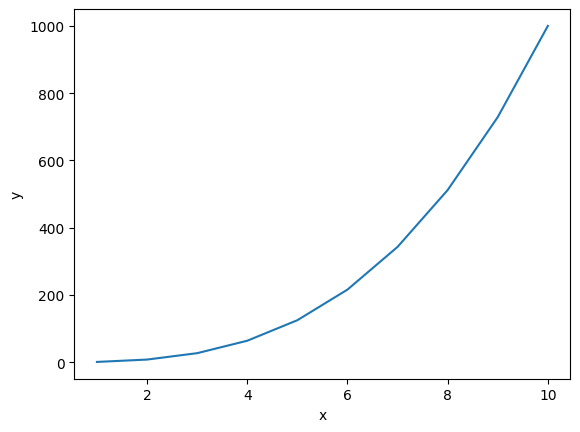

CPU times: total: 93.8 ms
Wall time: 184 ms


In [40]:
%%time
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = x ** 3

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### **13.2 正弦函数示例**

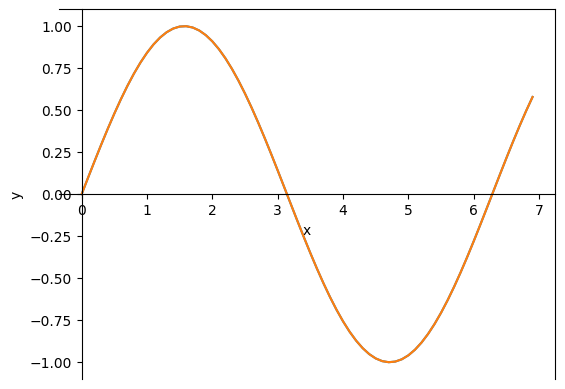

In [41]:
# 示例 1
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 7, 0.1)
y = np.sin(x)
#y = np.cos(x)

fig, ax = plt.subplots()
ax.plot(x, y)

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

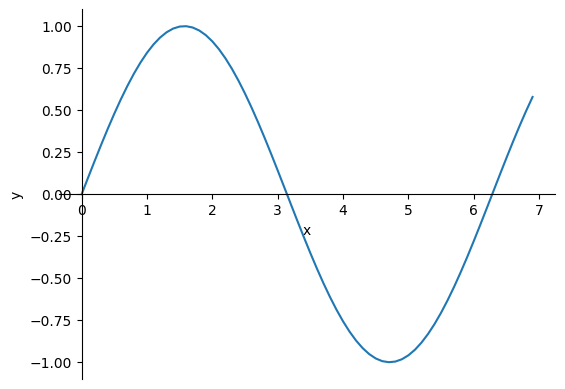

In [42]:
# 示例 2
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 7, .1)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y)

# 移动坐标轴到零点
for spine in ['left', 'bottom']:
    ax.spines[spine].set_position('zero')
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

## ⛵ **14. Scikit-learn 库使用示例**

### 🧬 **14.1 二分类任务 —— 逻辑回归**

#### **14.1.1 威斯康辛州乳腺癌数据集探索**

以 Scikit-learn 中自带的 **威斯康辛州乳腺癌数据集** 为例，演示如何使用此框架分割数据集，训练模型，筛选出对乳腺癌阳性相关性较强的多个特征变量，并给出模型预测的准确率与召回率。数据集包含 **569** 个样本，每个样本包含 **30** 个特征，即 **细胞核的定量形态学指标**，"10组统计量 x 3类量" 如下所述：

- 半径（半径均值、误差、最大值）
- 纹理（纹理均值、误差、最大值）
- 周长（周长均值、误差、最大值）
- 面积（面积均值、误差、最大值）
- 光滑度（光滑度均值、误差、最大值）
- 紧凑度（紧凑度均值、误差、最大值）
- 凹度（凹度均值、误差、最大值）
- 凹点（凹点数目均值、误差、最大值）
- 对称性（对称性均值、误差、最大值）
- 分形维数（分形维数均值、误差、最大值）

#### **14.1.2 生成数据集 header**

笔者环境中 Scikit-learn 安装于 Win11 环境中，根据以下命令获取模块安装路径，在此路径中可确定数据集位置。数据集位于 sklearn/datasets/data/breast_cancer.csv。

In [43]:
%pip show scikit-learn

Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: C:\Users\hualo\Programme Files\python-3.11.9-amd64\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: 
Note: you may need to restart the kernel to use updated packages.


直接打开数据集发现，并未给出每个特征的名称。因此，使用以下方式生成数据集 header（目标是生成带有特征名称的 DataFrame）：

In [44]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

In [45]:
data = load_breast_cancer()
#调试
#data
type(data.data)  # numpy.ndarray

numpy.ndarray

In [46]:
#调试
data.feature_names  # numpy.ndarray

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [47]:
df = pd.DataFrame(data.data, columns=data.feature_names)  # numpy.ndarray 数据类型可作为 pd.DataFrame() 参数；将特征名称作为列名称

In [48]:
df['target'] = data.target  # 将 data.target 索引的列赋值 DataFrame 中名为 target 列的值，此列作为目标变量。
df.to_csv('./data/breast_cancer_with_header.csv', index=False)  # DataFrame 生成 CSV 文件不带有 index 列

#### **14.1.3 判断数据集中样本是否平衡**

target 为 **0**（benign /bɪˈnaɪn/, 良性的）；target 为 **1**（malignant /məˈlɪɡnənt/，恶性的）

In [49]:
print("1. 目标变量数量：", df.target.value_counts())  # 计算二分类任务中目标变量（0 与 1）各自的数量
print("2. 目标变量占比：", round(df.target.value_counts(normalize=True), 3))  # 计算二分类任务中目标变量占总样本的百分比（浮点数计算）
ir = df.target.value_counts()[1] / df.target.value_counts()[0]
print(f"3. 数据集样本 IR: {ir:.2f}")  # 浮点数计算

1. 目标变量数量： target
1    357
0    212
Name: count, dtype: int64
2. 目标变量占比： target
1    0.627
0    0.373
Name: proportion, dtype: float64
3. 数据集样本 IR: 1.68


以上结果中 IR = 1.68，样本数据基本平衡，可保证预测准确率。

#### **14.1.4 观测每个特征的直方图**

**直方图绘制：**

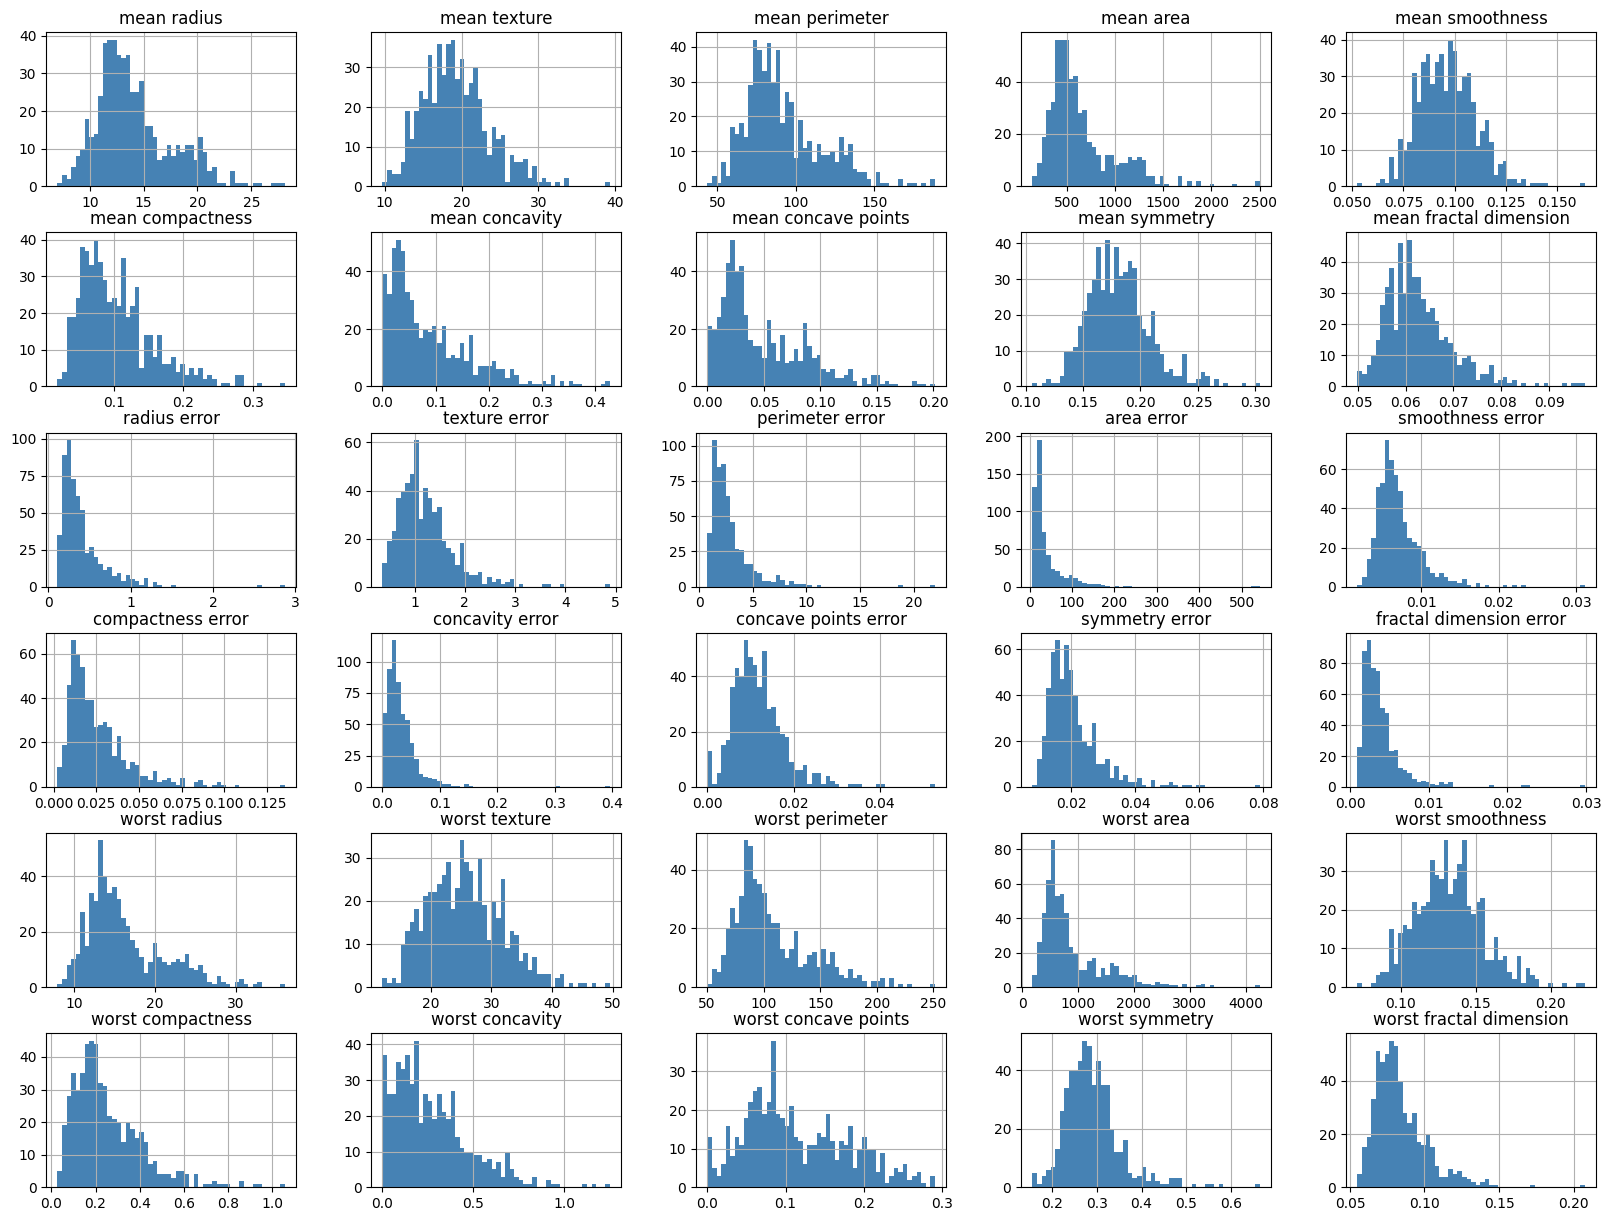

In [50]:
%matplotlib inline
data, target = load_breast_cancer(return_X_y=True)  # 返回的数据必须赋值 data 与 target
df = pd.DataFrame(data, columns=load_breast_cancer().feature_names)  # 构建含特征名的 DataFrame
df.hist(bins=50, figsize=(20,15), density=False, color='steelblue')
# bins=50：为每个特征设置 50 个等宽区间
# figsize=(20,15)：设置整张画布 30x15 英寸，每个直方图分布其中。
# density=False：纵轴为样本计数，density=True 为概率密度统计。
# color='steelblue'：直方图颜色
plt.show()

**直方图说明：**

- 横轴：特征值，即每个特征在数据集中的取值范围，单位与数据集中的一致。bins 设置等宽区间（单位区间），每个柱宽表示，若某个样本的特征值在该区间内，该样本被统计在内。
- 纵轴：样本在横轴区间上的数量统计（默认），也可以指定概率密度分布。

**分布重叠绘制：**

在单个特征中，阳性样本与阴性样本都可能在某些区间内被统计，那么就会产生 **分布重叠**，如果分布重叠越多，说明只通过该特征进行分类越不容易，需要通过其他特征一同分类。如下程序可用于单个特征中不同类型样本的分布重叠显示：

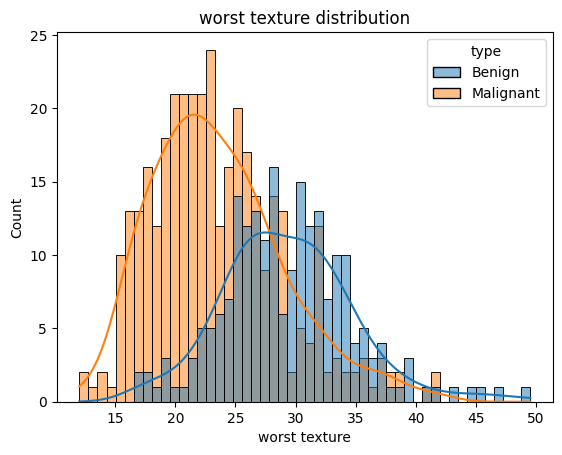

In [51]:
from sklearn.datasets import load_breast_cancer
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)  # 数据加载
df = pd.DataFrame(X, columns=load_breast_cancer().feature_names)
df['type'] = pd.Series(y).map({0:'Benign',1:'Malignant'})  # 将目标变量矩阵 y 中的值映射加标签

sns.histplot(data=df, x='worst texture', hue='type', bins=50, kde=True)  
# 使用 df DataFrame 数据绘图（只针对一种特征）
# hue='type'：把 type 列里的不同取值（良性/恶性）当成分组变量，每种分组用不同颜色画一根直方图，方便并排或叠在一起比较。
# kde=True：在直方图上方（或下方）再加一条核密度估计曲线（Kernel Density Estimate），平滑地显示概率密度形状，便于对比分布峰值与尾部。
plt.title('worst texture distribution')
plt.show()

#### **14.1.5 构建、训练与评估模型**

In [52]:
# file: scripts/logistic_roc_breast_cancer.py
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, RocCurveDisplay, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

In [53]:
# 1. 加载数据
X, y = load_breast_cancer(return_X_y=True)  
# return_X_y=True 参数：加载特征变量数据与目标变量数据
# 说明：
#   X：特征矩阵（row: n samples x column: n features）
#   y：目标标签（n samples x 0/1）
feature_names = load_breast_cancer().feature_names  # 获取列名（特征名）
#调试：
#data = load_breast_cancer().filename
#print(data)

In [54]:
# 2. 训练/测试拆分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
# 始终按照以上数据集的顺序拆分
# 说明：
#   1. test_size=0.25：按照原始数据集的 25% 的拆分为测试数据集，也可写成 train_size=0.75。
#   2. random_state=42：随机种子固定，每次划分的结果相同，可复现结果。random_state 的数值可任意整型数（如 0、42、43 等）。
#   3. stratify=y：按照原始数据集中 y 的比例分层抽样，保证训练、测试数据集中的目标变量（0/1）比例与原始一致，在数据不平衡的数据集中必用。

In [55]:
#调试：
target_p = 1
target_n = 0
p = np.sum(y_test == target_p)
print("测试数据集中的阳性样本（正例）数量（个）：", p)
n = (y_test == target_n).sum()  # 等价于 np.sum(y_test == target_n)
print("测试数据集中的阴性样本（负例）数量（个）：", n)

测试数据集中的阳性样本（正例）数量（个）： 90
测试数据集中的阴性样本（负例）数量（个）： 53


In [56]:
# 3. 管道：标准化 + 逻辑回归
pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])  # 迭代次数默认 100 次，此处指定 1000 次，保证模型收敛。
pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [57]:
#调试：标准化
mu_mean = pipe.named_steps['scaler'].mean_
sigma_std = pipe.named_steps['scaler'].scale_
z = pipe.named_steps['scaler'].transform(X_train)
#print("1. 每个特征（列）的均值：", mu_mean)
#print("2. 每个特征（列）的标准差：", sigma_std)
print("3. 每个样本的 z-score：", np.round(z, 3))

3. 每个样本的 z-score： [[ 1.659  0.217  1.611 ...  0.702 -0.556  0.389]
 [-0.338 -1.39  -0.402 ... -0.901 -0.924 -0.797]
 [ 0.874 -0.652  1.01  ...  2.097  1.767  1.165]
 ...
 [ 0.395  1.048  0.505 ...  1.521  0.155  1.208]
 [ 0.849 -0.048  0.903 ...  2.086  0.302  0.349]
 [-1.226 -0.519 -1.204 ... -0.905 -0.581  0.032]]


📈 以上每个训练样本的每个特征（列）的 **z-score** 计算公式：$$z_{ij} = \frac{x_{ij} - \mu_{j}}{\sigma_{j}}$$  其中：$i$ 代表第几行，$j$ 代表第几列，$\mu_{j}$ 是每个特征（列）的平均值，$\sigma_{j}$ 是每个特征（列）的标准差。

In [58]:
#调试：逻辑回归
classes = pipe.named_steps['clf'].classes_  # 获取分类的类别（0 为负例；1 为正例），确定样本的正例还是负例需从原始数据考虑。
print("Classes: ", classes)
coef = pipe.named_steps['clf'].coef_[0]  # 系数绝对值
print("Coef: ", coef)

Classes:  [0 1]
Coef:  [-0.5230639  -0.51866977 -0.48369147 -0.55733419 -0.3010073   0.69423027
 -0.56544331 -0.6769288  -0.12623296  0.08371349 -1.0701021   0.26071433
 -0.49107245 -0.94105896 -0.14558343  0.61642565  0.15410769 -0.34398572
  0.42510152  0.37488172 -0.91747951 -1.25014919 -0.72116803 -0.92581178
 -0.6696476   0.04658657 -0.79675795 -0.94188817 -0.95704524 -0.20956757]


🎢 此逻辑回归训练过程中使用的目标函数（损失函数）：**负对数似然（Negative Log-Likelihood，NLL）+ L2 正则**，也称为二分类的 **交叉熵**。
$$
  \begin{align*}
    \mathcal{L}(w, b) = -\frac{1}{n} \sum\limits_{i=1}\limits^{n} \bigg[y_i\ log\ p_i + (1 - y_i)\ log\ (1 - p_i)\bigg] + \frac{\lambda}{2} \Vert{w}\Vert^2
  \end{align*}
$$
其中：$p_i = \sigma(z_i) = \frac{1}{1 + e^{-z_{i}}}$，$z_i = w_i \cdot x_i + b$。此处的 $z_i$ 与前文的 z-score 无关。

🔎 **<span style="color:blue">逻辑回归训练与预测过程</span>**：此训练样本共 30 个特征，共计 30 个权重 $w$ 组成矩阵 $\mathbf{w}$，它与 $b$ 初始化为 0 后，经过计算 NLL 梯度与 **L-BFGS** 算法迭代更新后，获得最终的 $\mathbf{w}$ 与 $b$。将其输入 $z = \mathbf{w}^\top\mathbf{x} + b$ 得到线性值 $z$（$\mathbf{x}$ 是每个样本的 z-score 矩阵），通过 $\sigma(z) = sigmoid(z) = \frac{1}{1 + e^{-z}}$ 得到最终的分类概率。**L-BFGS 算法一次性读取全部样本进行训练，不使用小批量样本方式训练。** 如果使用小批量训练，可采用 **SGDClassifier** 类实例化对象后训练。无论是 L-BFGS 算法还是 SGDClassifier 类都属于参数优化算法，都采用梯度迭代更新 $w$ 和 $b$。两者在于更新的方式不同，而在获得 $\mathbf{w}$ 与 $b$ 后的处理方法完全相同。

In [59]:
# 4. 预测概率 & 类别
y_score = pipe.predict_proba(X_test)[:, 1]  # 测试集正例样本的概率（probability）
#y_score = pipe.predict_proba(X_test)[:, 0]  # 测试集负例样本的概率
y_pred = pipe.predict(X_test)    # 数据集预测的 0/1 类别

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:  0.99

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [60]:
#调试：
#print("1. 测试集 y_score 概率：", y_score)
#print("2. 测试集 y_pred 预测标签：", y_pred)

In [61]:
# 5. 与恶性最相关的特征（系数绝对值）
coef = pd.Series(pipe.named_steps['clf'].coef_[0], index=feature_names)  # 系数绝对值，即特征权重向量（w），该值的绝对值越大对正例影响越大。
top_malignant = coef.sort_values(key=abs, ascending=False).head(10)  # key=abs 参数：绝对值，ascending=False 参数：从大到小排列
print("与恶性 (Malignant) 最相关的 10 个特征：")
print(top_malignant)

与恶性 (Malignant) 最相关的 10 个特征：
worst texture          -1.250149
radius error           -1.070102
worst symmetry         -0.957045
worst concave points   -0.941888
area error             -0.941059
worst area             -0.925812
worst radius           -0.917480
worst concavity        -0.796758
worst perimeter        -0.721168
mean compactness        0.694230
dtype: float64


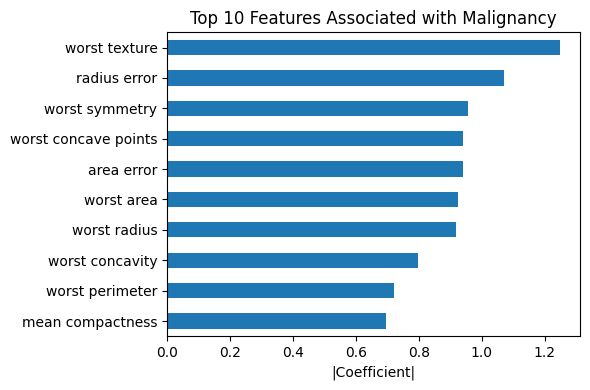

In [62]:
# 6. 特征重要性条形图
plt.figure(figsize=(6, 4))  # 新建一张 6 英寸宽、4 英寸高的空白画布，防止默认尺寸太小。
top_malignant.abs().sort_values(ascending=True).plot.barh()  # 取 10 个影响最大的系数绝对值，从下往上（从小到大）排列，绘制条形图。
plt.title("Top 10 Features Associated with Malignancy")
plt.xlabel("|Coefficient|")
plt.tight_layout()  # 自动收紧空白，防止标签/标题被截断。
plt.show()

In [63]:
# 7. 混淆矩阵
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

In [64]:
#调试：
#cm.ravel()
cm
# 根据 labels=[0, 1]，行为实际值，列为预测值，混淆矩阵的排列为：
#    0    1
# 0  TN  FP
# 1  FN  TP

array([[52,  1],
       [ 1, 89]])

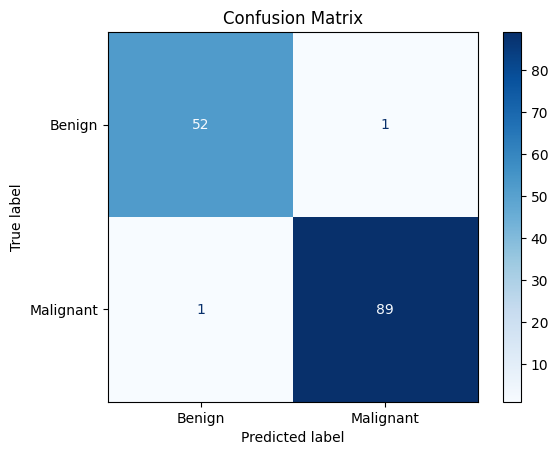

In [65]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Benign', 'Malignant'])  # Benign：良性；Malignant：恶性
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

AUC = 0.998


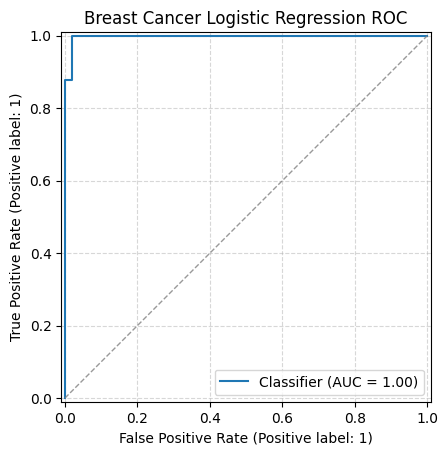

In [66]:
# 8. ROC 曲线
auc = roc_auc_score(y_test, y_score)
print(f"AUC = {auc:.3f}")

RocCurveDisplay.from_predictions(y_test, y_score)
# --- 网格 + 对角线 ---
ax = plt.gca()  # 获取当前轴
ax.grid(True, linestyle='--', alpha=0.5)  # 网格
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.8)  # 对角线
# -----------------------------
plt.title("Breast Cancer Logistic Regression ROC")
plt.show()

### 💐 **14.2 多分类任务 —— 逻辑回归**

#### **14.2.1 鸢尾花数据集探索**

- Iris 也称鸢尾花卉数据集，是一类多重变量分析的数据集。数据集包含 150 个数据样本，分为 3 类（花卉种类分型），每类 50 个数据，每个数据包含 4 个属性。
- 可通过 **花萼长度**，**花萼宽度**，**花瓣长度**，**花瓣宽度** 4 个属性预测鸢尾花卉属于 Iris Setosa（山鸢尾）、Iris Versicolour（杂色鸢尾）以及 Iris Virginica（维吉尼亚鸢尾）三个种类中的哪一类。
- 以鸢尾花的特征作为数据来源，常用在 **分类操作** 中。其中的一个种类与另外两个种类是线性可分离的，后两个种类是非线性可分离的。这是 Iris 数据集的经典结构特征，也是常被用作 “线性 vs 非线性” 对比案例的原因。
- 📊 Iris 数据集中：
  - ✔️ Setosa（0）与 Versicolor（1）+ Virginica（2）：**<span style="color:red">线性可分离</span>**
  - ✔️ Versicolor（1）与 Virginica（2）：**<span style="color:red">非线性可分离</span>**
- 该数据集包含了 4 个属性：
  - Sepal Length（花萼长度）：单位 cm
  - Sepal Width（花萼宽度）：单位 cm
  - Petal Length（花瓣长度）：单位 cm
  - Petal Width（花瓣宽度）：单位 cm

In [67]:
import pandas as pd
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
#print("1. 鸢尾花数据集样本数据：", X)
#print("2. 鸢尾花数据集目标变量：", y)
df_iris = pd.DataFrame(X, columns=load_iris().feature_names)
df_iris['target'] = y
df_iris.to_csv('./data/iris_classification.csv', index=False)
print("\n鸢尾花数据集 DataFrame：\n")
#df_iris.values
df_iris


鸢尾花数据集 DataFrame：



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


#### **14.2.2 构建、训练与评估模型**

Accuracy: 0.84

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.77      0.77      0.77        13
           2       0.79      0.85      0.81        13

    accuracy                           0.84        38
   macro avg       0.85      0.84      0.85        38
weighted avg       0.85      0.84      0.84        38

Logistic Regression – Iris Confusion Matrix:
 [[11  1  0]
 [ 0 10  3]
 [ 0  2 11]]


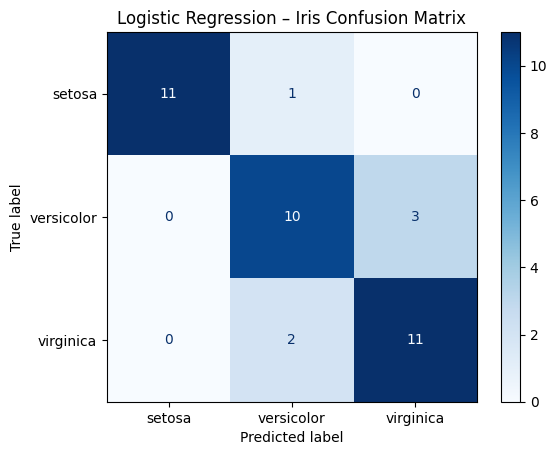

<Figure size 600x500 with 0 Axes>

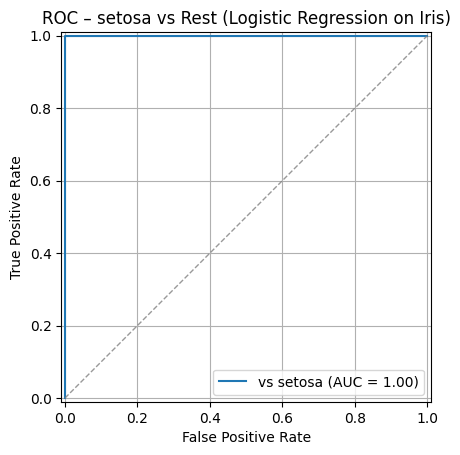

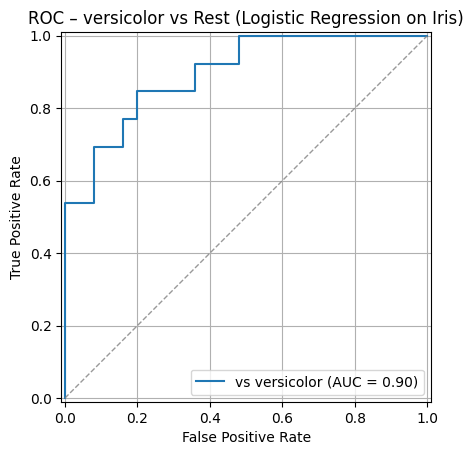

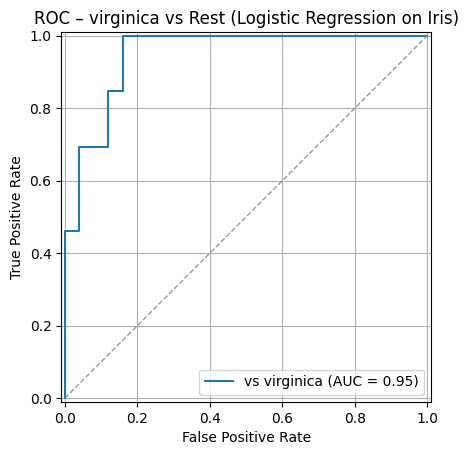

In [68]:
# scripts/logistic_multiclass_iris.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

# 1. 数据
X, y = load_iris(return_X_y=True)

# 2. 训练/测试拆分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# 3. 管道：标准化 + 逻辑回归
pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', OneVsRestClassifier(
         LogisticRegression(max_iter=1000,
                            class_weight='balanced')))
])  # 多分类任务

pipe.fit(X_train, y_train)

# 4. 预测与评估
y_score = pipe.predict_proba(X_test)
y_pred = pipe.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print("Logistic Regression – Iris Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=load_iris().target_names)
disp.plot(cmap='Blues')
plt.title("Logistic Regression – Iris Confusion Matrix")
plt.show()

# 6. 为 3 类分别绘制 ROC 曲线
plt.figure(figsize=(6, 5))
for idx, cls_name in enumerate(load_iris().target_names):
    RocCurveDisplay.from_predictions(
        y_test == idx,
        y_score[:, idx],
        name=f"vs {cls_name}",
    )
    ax = plt.gca()
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.8)  # 对角线
    plt.title(f"ROC – {cls_name} vs Rest (Logistic Regression on Iris)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.show()

#### 📝 **14.2.3 总结**：

- ✔️ 逻辑回归虽然用了 `sigmoid` 激活函数输出概率，但 **决策边界** 仍然是 $\mathbf{w}^\top \mathbf{x} + b = 0$ 线性的（在二维特征空间中是一条直线；在三维特征空间中是一个平面；在更高维中是超平面），因此它本质上是线性分类器（二分类或多分类）。
- ✔️ 威斯康辛州乳腺癌数据集测试集 Accuracy 为 99%，说明使用逻辑分类可达到极高的二分类效果。
- ✔️ 鸢尾花数据集测试集 Accuracy 为 84%，类别0可达到 100% Precision，但是类别1与类别2的 Precision 低于 80%，说明这两类的分类效果不佳。这个结论也从侧面反映此数据集的特性。因此，单纯使用逻辑回归这种线性分类器不能很好区分后两种类别，可选择如 **神经网络模型** 进行分类。
- ✔️ 无论二元或多元分类，都根据混合矩阵中每个类别的 TP, FN, FP, TN 独立计算。

## **15. PyTorch 库使用示例**

### **15.1 张量（tensor）生成示例**

In [69]:
import numpy as np
import pandas as pd
import torch

# 示例1：张量数据来自 numpy.ndarray
np1 = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
tensor_np = torch.tensor(np1, dtype=torch.int64)
print(tensor_np)

# 示例2：张量数据来自 DataFrame
df = pd.read_csv('./data/us_tornado_dataset_1950_2021.csv')
tensor_df = torch.tensor(df.slat, dtype=torch.float32)
print(tensor_df)

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])
tensor([39.1000, 38.7700, 40.8800,  ..., 34.2875, 33.7372, 33.5676])


### 🥇 **15.2 多分类任务 —— 人工神经网络（Artificial Neural Network, ANN）**

#### **15.2.1 构建、训练与评估 ANN**

从前文 14.2 节中可知逻辑回归对鸢尾花数据集的 **后两种类别** 分类不理想，因此，选择 ANN 进行分类训练与预测。

In [70]:
# 导入必要的库
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [71]:
# 加载数据集
iris = load_iris()
X = iris.data  # 特征
y = iris.target  # 标签

In [72]:
# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [73]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [74]:
# 转换为 PyTorch 张量
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [75]:
# 创建数据加载器
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [76]:
# ANN 模型定义
class ANN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

In [77]:
# 初始化模型参数
input_size = X_train.shape[1]  # 4个特征
hidden_size = 10  # 隐藏层神经元数量
num_classes = len(np.unique(y))  # 3个类别

model = ANN(input_size, hidden_size, num_classes)

In [78]:
# 定义损失函数与优化器
criterion = nn.CrossEntropyLoss()  # 多分类任务常用交叉熵损失
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adam优化器

In [79]:
# 训练集数据训练
num_epochs = 100
for epoch in range(num_epochs):
    for batch_X, batch_y in train_loader:
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.5791
Epoch [20/100], Loss: 0.0293
Epoch [30/100], Loss: 0.2394
Epoch [40/100], Loss: 0.0026
Epoch [50/100], Loss: 0.0031
Epoch [60/100], Loss: 0.0024
Epoch [70/100], Loss: 0.0036
Epoch [80/100], Loss: 0.0025
Epoch [90/100], Loss: 0.0003
Epoch [100/100], Loss: 0.0020


In [80]:
# 预测测试集
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)

In [81]:
# 计算准确率
accuracy = accuracy_score(y_test_tensor, predicted)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9667


In [82]:
# 详细的分类报告
print('Classification Report:')
print(classification_report(y_test_tensor, predicted, target_names=iris.target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      1.00      0.95         9
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]


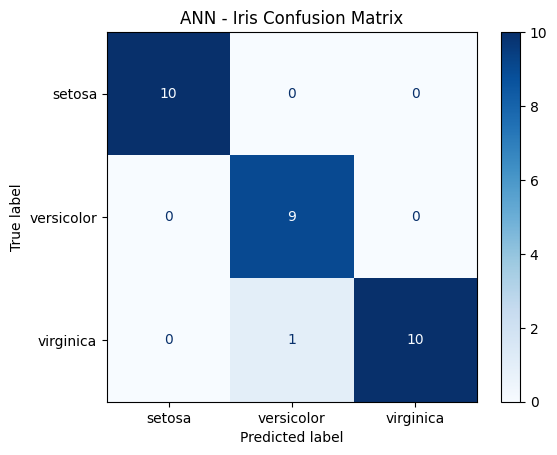

In [83]:
# 混淆矩阵
cm = confusion_matrix(y_test_tensor, predicted)
print('Confusion Matrix:')
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=load_iris().target_names)
disp.plot(cmap='Blues')
plt.title("ANN - Iris Confusion Matrix")
plt.show()

#### **15.2.2 绘制决策边界**

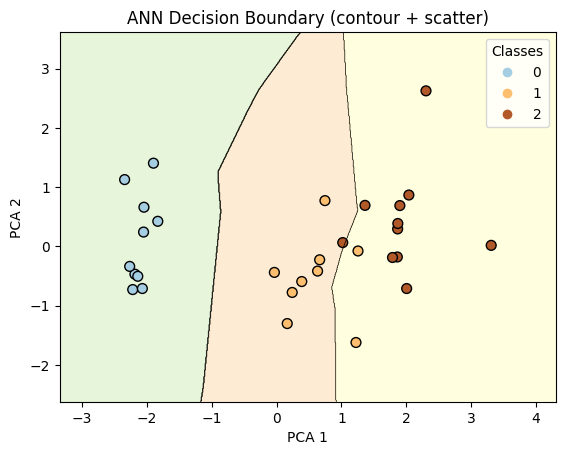

In [84]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 为了可视化，我们降维到2维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 重新训练模型（基于2维数据）
X_train_pca_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_pca_tensor = torch.tensor(y_train_pca, dtype=torch.long)
X_test_pca_tensor = torch.tensor(X_test_pca, dtype=torch.float32)

train_dataset_pca = TensorDataset(X_train_pca_tensor, y_train_pca_tensor)
train_loader_pca = DataLoader(train_dataset_pca, batch_size=16, shuffle=True)

# 重新定义模型（输入维度为2）
model_pca = ANN(input_size=2, hidden_size=10, num_classes=3)
optimizer_pca = optim.Adam(model_pca.parameters(), lr=0.01)

# 训练
for epoch in range(100):
    for batch_X, batch_y in train_loader_pca:
        outputs = model_pca(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer_pca.zero_grad()
        loss.backward()
        optimizer_pca.step()

# 绘制决策边界
def plot_decision_boundary(model, X, y):
    h = 0.01
    xx, yy = np.meshgrid(np.arange(X[:, 0].min() - 1, X[:, 0].max() + 1, h),
                         np.arange(X[:, 1].min() - 1, X[:, 1].max() + 1, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = model(grid).argmax(1).numpy().reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=2, alpha=0.3, cmap=plt.cm.Paired)
    plt.contour(xx, yy, Z, levels=2, colors='k', linewidths=0.5)  # 黑边
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired, s=50)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
    plt.title('ANN Decision Boundary (contour + scatter)')
    plt.show()

plot_decision_boundary(model_pca, X_test_pca, y_test_pca)

## **参考链接**

- [现今的机器学习介绍](https://opensource.com/article/17/9/introduction-machine-learning)
- [什么是 MLOps？](https://www.redhat.com/en/topics/ai/what-is-mlops)
- [红帽 AI/ML 与 MLOps 客户成功故事](https://www.redhat.com/en/blog/red-hat-ai/ml-and-mlops-customer-success-stories)
- [开发人员与数据科学家的五大协作方式](https://www.redhat.com/en/resources/top-5-ways-developers-collaborate-checklist)
- [Jupyter 项目主页](https://jupyter.org/)
- [JupyterLab 文档](https://jupyterlab.readthedocs.io/en/3.6.x/index.html)
- [ipykernel](https://docs.jupyter.org/en/latest/projects/kernels.html#term-ipykernel)
- [Jupyter 内核列表](https://github.com/jupyter/jupyter/wiki/Jupyter-kernels)
- [Jupyter 内置魔法命令](https://ipython.readthedocs.io/en/stable/interactive/magics.html)
- [Git 工作流](https://nvie.com/posts/a-successful-git-branching-model/)
- [GitHub 工作流](https://docs.github.com/en/get-started/using-github/github-flow)
- [基于主干的开发](https://trunkbaseddevelopment.com/)
- [jupyterlab-git: 使用 Git 进行版本控制的 JupyterLab 扩展](https://github.com/jupyterlab/jupyterlab-git)
- [nbdime: 比较和合并 Jupyter Notebook](https://nbdime.readthedocs.io/en/stable/)